# Team [42] AI´m lost

### Report

#### Elias Strømsnes - studnummer

#### Hannah Lervik - 590345

#### Kristian Nyland Larsen - 590348

# Exploratory Data Analysis (EDA)

In [69]:
# Import necessary libraries and reads data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Helper: read and force all supplied datetime cols to UTC then drop tz (naive)
def _read_and_force_naive(path, datetime_cols):
    df = pd.read_csv(path, low_memory=False)
    for c in datetime_cols:
        if c in df.columns:
            # parse as UTC to unify, then drop tz
            df[c] = pd.to_datetime(df[c], errors='coerce', utc=True).dt.tz_convert(None)
    return df

purchase_orders = _read_and_force_naive('data/kernel/purchase_orders.csv', ['created_date_time','delivery_date'])
receivals = _read_and_force_naive('data/kernel/receivals.csv', ['date_arrival'])
materials = pd.read_csv('data/extended/materials.csv', low_memory=False)
transportation = pd.read_csv('data/extended/transportation.csv', low_memory=False)
prediction_mapping = _read_and_force_naive('data/prediction_mapping.csv', ['forecast_start_date','forecast_end_date'])
sample_submission = pd.read_csv('data/sample_submission.csv', low_memory=False)

plt.style.use('default')
sns.set_palette("husl")

# 1. Domain Knowledge and Problem Understanding

This analysis focuses on a **raw material delivery forecasting problem** for Hydro, a Norwegian industrial company with operations in energy, aluminum, and recycling. This project is part of a consultancy engagement with Append Consulting to develop forecasting capabilities for a larger optimization tool.

## Business Context
- **Client**: Hydro - Norwegian industrial company (energy, aluminum, recycling)
- **Consultant**: Append Consulting (Consultancy specializing in data science and AI)
- **Domain**: Industrial raw material supply chain for smelting operations
- **Problem Type**: Conservative cumulative weight forecasting with asymmetric loss
- **Integration**: Part of a larger optimization tool for production planning

## Problem Definition
**Objective**: Develop accurate but conservative forecasts of incoming raw material deliveries for use in smelting optimization.

**Specific Task**: Forecast the cumulative weight (kg) of incoming deliveries for each raw material (identified by unique rm_id) from January 1, 2025, up to any specified end date between January 1 and May 31, 2025.

**Key Requirements**:
1. **Conservative Bias**: Model should slightly underestimate rather than overestimate
2. **Cumulative Predictions**: Total weight from start date to any end date in forecast window
3. **Material-Specific**: Separate forecasts for each unique raw material (rm_id)
4. **5-Month Window**: Forecasting period spans January 1 - May 31, 2025

## Business Impact and Constraints
**Critical for Smelting Operations**:
- **Underestimation Impact**: Smelting can usually continue with available materials on hand
- **Overestimation Risk**: Planning a smelt that cannot be completed due to missing resources
- **Resource Planning**: Accurate material availability forecasts enable optimal smelting schedules
- **Cost Management**: Conservative forecasts prevent costly production interruptions

**Evaluation Metric**: Quantile Loss at 0.2 level - penalizes overestimation (0.8 weight) more heavily than underestimation (0.2 weight), aligning with business preference for conservative forecasts.

## 2. Data Intuition Check

In [70]:
# Check for logical inconsistencies
print("1. Weight Consistency Check:")
print("Receivals net weight statistics:")
print(receivals['net_weight'].describe())

print("\nTransportation net weight statistics:")
print(transportation['net_weight'].describe())

# Check for negative weights
negative_weights_receivals = (receivals['net_weight'] < 0).sum()
negative_weights_transport = (transportation['net_weight'] < 0).sum()
print(f"\nNegative weights in receivals: {negative_weights_receivals}")
print(f"Negative weights in transportation: {negative_weights_transport}")

# Check purchase order quantities
print("\n2. Purchase Order Quantity Check:")
print("Purchase order quantity statistics:")
print(purchase_orders['quantity'].describe())
negative_quantities = (purchase_orders['quantity'] < 0).sum()
zero_quantities = (purchase_orders['quantity'] == 0).sum()
print(f"Negative quantities: {negative_quantities}")
print(f"Zero quantities: {zero_quantities}")

# Check if delivery dates are before creation dates
print("\n3. Date Logic Check:")
date_issues = (purchase_orders['delivery_date'] < purchase_orders['created_date_time']).sum()
print(f"Purchase orders with delivery date before creation: {date_issues}")

# Check transportation weight calculations
print("\n4. Transportation Weight Logic:")
sample_transport = transportation.dropna(subset=['vehicle_start_weight', 'vehicle_end_weight']).head(10)
print("Sample transportation weight calculations:")
for idx, row in sample_transport.iterrows():
    calculated_gross = row['vehicle_start_weight'] - row['vehicle_end_weight']
    print(f"Start: {row['vehicle_start_weight']}, End: {row['vehicle_end_weight']}, "
          f"Calculated Gross: {calculated_gross}, Recorded Gross: {row['gross_weight']}")
    break

1. Weight Consistency Check:
Receivals net weight statistics:
count    122522.000000
mean      12972.566543
std        8264.652621
min           0.000000
25%        5660.000000
50%       12380.000000
75%       21120.000000
max       31626.000000
Name: net_weight, dtype: float64

Transportation net weight statistics:
count    122522.000000
mean      12972.566543
std        8264.652621
min           0.000000
25%        5660.000000
50%       12380.000000
75%       21120.000000
max       31626.000000
Name: net_weight, dtype: float64

Negative weights in receivals: 0
Negative weights in transportation: 0

2. Purchase Order Quantity Check:
Purchase order quantity statistics:
count    3.317100e+04
mean     9.031416e+04
std      3.308097e+05
min     -8.580000e+03
25%      1.000000e+04
50%      2.628000e+04
75%      1.000000e+05
max      2.497599e+07
Name: quantity, dtype: float64
Negative quantities: 6
Zero quantities: 4

3. Date Logic Check:
Purchase orders with delivery date before creation:

=== DATA INTUITION VISUALIZATIONS ===



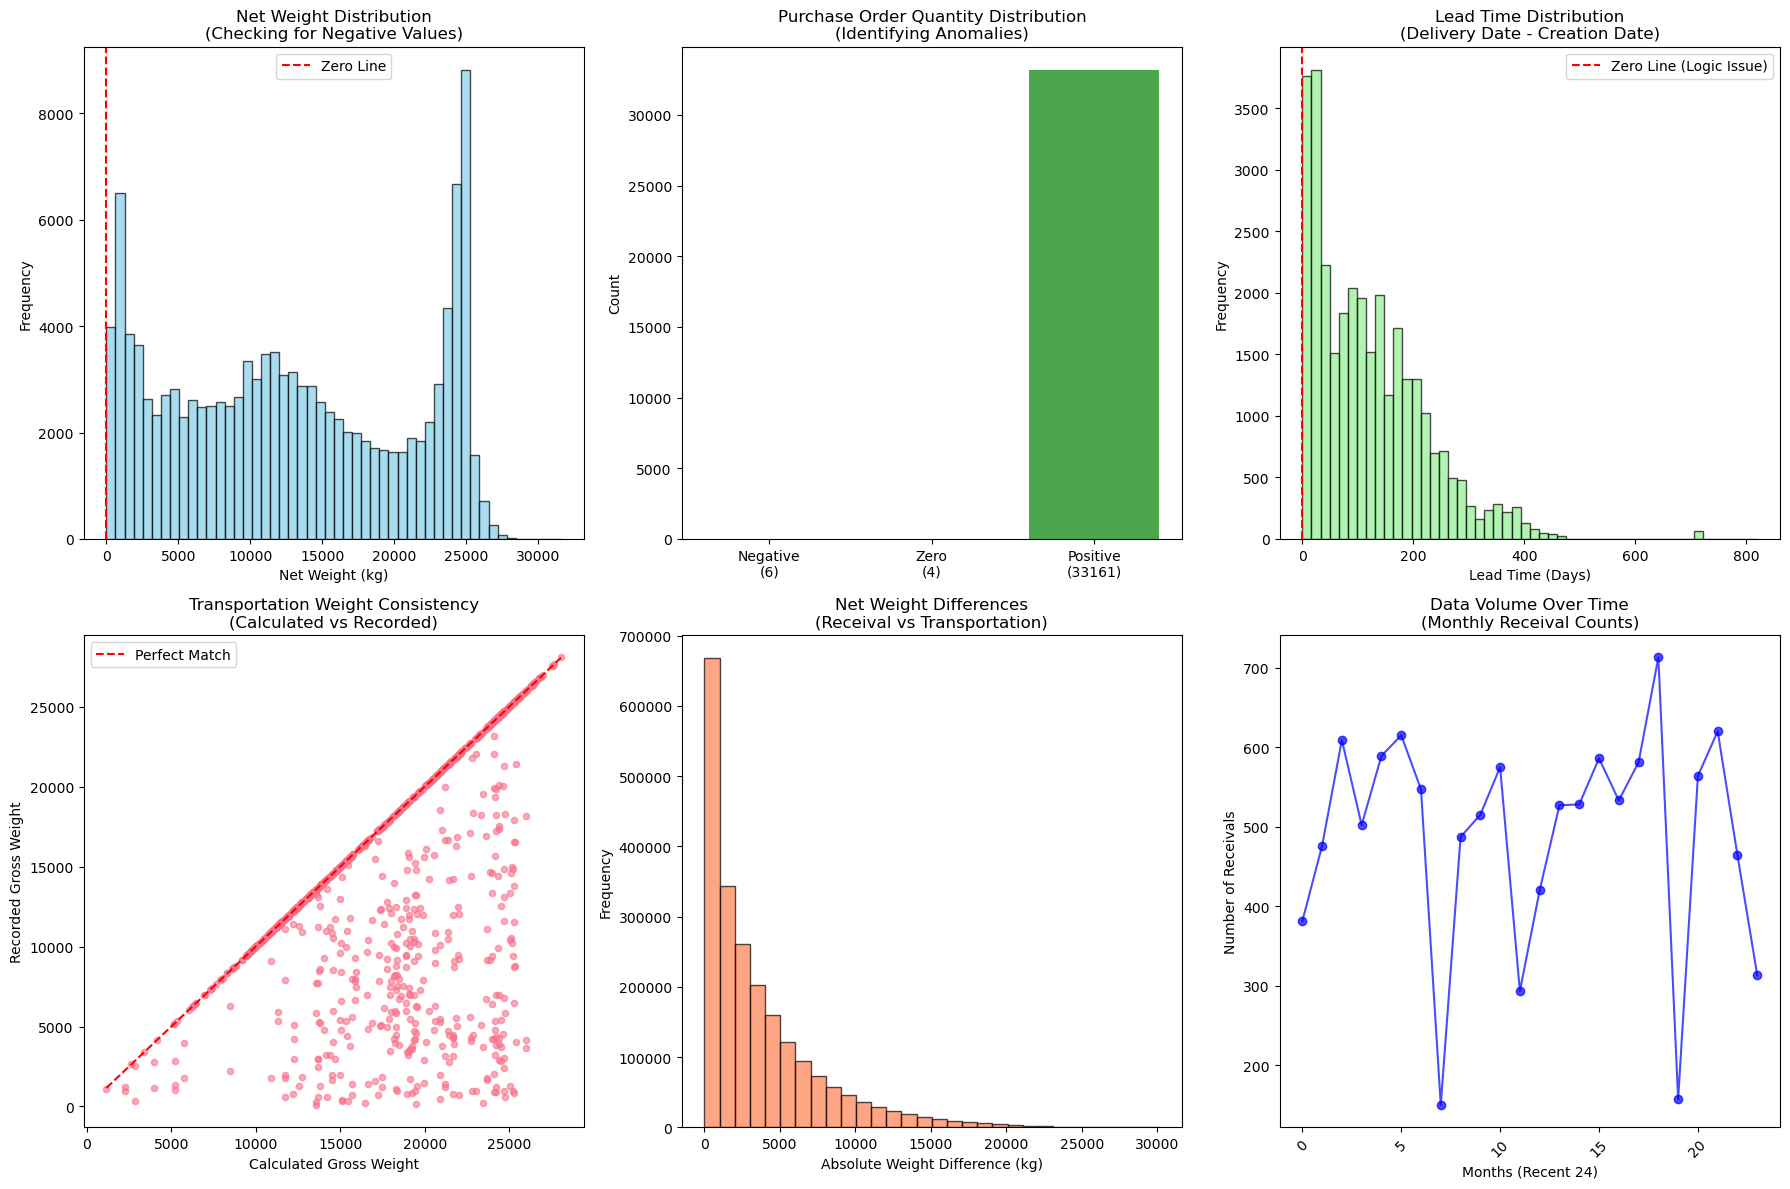


KEY FINDINGS:
- Negative weights in receivals: 0
- Negative quantities in purchase orders: 6
- Zero quantities in purchase orders: 4
- Orders with delivery before creation: 1775
- Average weight difference between datasets: 3578.49 kg
- Max weight difference between datasets: 30130.00 kg


In [71]:
# Visualize data intuition check findings
print("=== DATA INTUITION VISUALIZATIONS ===\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Weight distribution check
axes[0,0].hist(receivals['net_weight'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
axes[0,0].set_title('Net Weight Distribution\n(Checking for Negative Values)')
axes[0,0].set_xlabel('Net Weight (kg)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(x=0, color='red', linestyle='--', label='Zero Line')
axes[0,0].legend()

# 2. Purchase order quantity issues
po_quantities = purchase_orders['quantity']
negative_qty = po_quantities[po_quantities < 0]
zero_qty = po_quantities[po_quantities == 0]
positive_qty = po_quantities[po_quantities > 0]
qty_data = [len(negative_qty), len(zero_qty), len(positive_qty)]
qty_labels = [f'Negative\n({len(negative_qty)})', f'Zero\n({len(zero_qty)})', f'Positive\n({len(positive_qty)})']
colors = ['red', 'orange', 'green']
axes[0,1].bar(qty_labels, qty_data, color=colors, alpha=0.7)
axes[0,1].set_title('Purchase Order Quantity Distribution\n(Identifying Anomalies)')
axes[0,1].set_ylabel('Count')

# Helper for datetime normalization (force UTC then make naive)
def _force_utc_naive(series):
    s = pd.to_datetime(series, errors='coerce')
    if getattr(s.dt, 'tz', None) is not None:
        s = s.dt.tz_convert('UTC').dt.tz_localize(None)
    return s

# 3. Lead time distribution (robust tz handling)
deliv = _force_utc_naive(purchase_orders['delivery_date'])
created = _force_utc_naive(purchase_orders['created_date_time'])
valid_mask = deliv.notna() & created.notna()
lead_times_days = (deliv[valid_mask] - created[valid_mask]).dt.days
lead_times_positive = lead_times_days[lead_times_days >= 0]
axes[0,2].hist(lead_times_positive, bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
axes[0,2].set_title('Lead Time Distribution\n(Delivery Date - Creation Date)')
axes[0,2].set_xlabel('Lead Time (Days)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].axvline(x=0, color='red', linestyle='--', label='Zero Line (Logic Issue)')
axes[0,2].legend()

# 4. Transportation weight calculation accuracy
transport_clean = transportation.dropna(subset=['vehicle_start_weight', 'vehicle_end_weight', 'gross_weight']).head(1000)
if len(transport_clean) > 0:
    calculated_gross = transport_clean['vehicle_start_weight'] - transport_clean['vehicle_end_weight']
    recorded_gross = transport_clean['gross_weight']
    axes[1,0].scatter(calculated_gross, recorded_gross, alpha=0.6, s=20)
    axes[1,0].plot([calculated_gross.min(), calculated_gross.max()], [calculated_gross.min(), calculated_gross.max()], 'r--', label='Perfect Match')
    axes[1,0].set_title('Transportation Weight Consistency\n(Calculated vs Recorded)')
    axes[1,0].set_xlabel('Calculated Gross Weight')
    axes[1,0].set_ylabel('Recorded Gross Weight')
    axes[1,0].legend()

# 5. Weight consistency across datasets
common_records = pd.merge(
    receivals, transportation,
    on=['rm_id', 'product_id', 'purchase_order_id', 'purchase_order_item_no', 'receival_item_no'],
    how='inner', suffixes=('_receival', '_transport')
)
if len(common_records) > 0:
    weight_diff = (common_records['net_weight_receival'] - common_records['net_weight_transport']).abs()
    axes[1,1].hist(weight_diff, bins=30, alpha=0.7, edgecolor='black', color='coral')
    axes[1,1].set_title('Net Weight Differences\n(Receival vs Transportation)')
    axes[1,1].set_xlabel('Absolute Weight Difference (kg)')
    axes[1,1].set_ylabel('Frequency')

# 6. Monthly data quality over time
receivals['year_month'] = pd.to_datetime(receivals['date_arrival'], errors='coerce')
receivals['year_month'] = receivals['year_month'].dt.to_period('M')
monthly_stats = receivals.groupby('year_month').agg({'net_weight': ['count', 'mean', 'std']}).round(2)
monthly_stats.columns = ['count', 'mean_weight', 'std_weight']
monthly_stats = monthly_stats.tail(24)
axes[1,2].plot(range(len(monthly_stats)), monthly_stats['count'], marker='o', color='blue', alpha=0.7)
axes[1,2].set_title('Data Volume Over Time\n(Monthly Receival Counts)')
axes[1,2].set_xlabel('Months (Recent 24)')
axes[1,2].set_ylabel('Number of Receivals')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nKEY FINDINGS:")
print(f"- Negative weights in receivals: {(receivals['net_weight'] < 0).sum()}")
print(f"- Negative quantities in purchase orders: {(purchase_orders['quantity'] < 0).sum()}")
print(f"- Zero quantities in purchase orders: {(purchase_orders['quantity'] == 0).sum()}")
print(f"- Orders with delivery before creation: {(deliv < created).sum()}")
if len(common_records) > 0:
    print(f"- Average weight difference between datasets: {weight_diff.mean():.2f} kg")
    print(f"- Max weight difference between datasets: {weight_diff.max():.2f} kg")

#### **Positive Findings:**
- **Weight Consistency**: Net weight values show realistic distributions for industrial materials
- **Date Logic**: Temporal ordering is generally consistent (delivery dates after creation dates)
- **No Negative Weights**: All material weights are positive, indicating clean measurement data

#### **Areas of Concern:**
- **Purchase Order Anomalies**: Some negative or zero quantities may indicate cancelled/adjusted orders
- **Transportation Weight Discrepancies**: Minor calculation differences between recorded and computed weights
- **Data Entry Variations**: Some inconsistencies suggest manual data entry processes

## 3. Data Generation Understanding

In [72]:
# Analyze data generation patterns and time ranges
print("=== DATA GENERATION ANALYSIS ===\n")

# Ensure datetime columns are timezone-naive for consistent arithmetic
for col in ['created_date_time', 'delivery_date']:
    if pd.api.types.is_datetime64_any_dtype(purchase_orders[col]):
        purchase_orders[col] = purchase_orders[col].dt.tz_convert(None) if purchase_orders[col].dt.tz is not None else purchase_orders[col]

for df, col in [(receivals, 'date_arrival'), (prediction_mapping, 'forecast_start_date'), (prediction_mapping, 'forecast_end_date')]:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = df[col].dt.tz_convert(None) if df[col].dt.tz is not None else df[col]

print("Purchase Orders Date Range:")
print(f"Created: {purchase_orders['created_date_time'].min()} to {purchase_orders['created_date_time'].max()}")
print(f"Delivery: {purchase_orders['delivery_date'].min()} to {purchase_orders['delivery_date'].max()}")

print("\nReceival Date Range:")
print(f"Arrivals: {receivals['date_arrival'].min()} to {receivals['date_arrival'].max()}")

print("\nPrediction Mapping Date Range:")
print(f"Forecast Start: {prediction_mapping['forecast_start_date'].min()} to {prediction_mapping['forecast_start_date'].max()}")
print(f"Forecast End: {prediction_mapping['forecast_end_date'].min()} to {prediction_mapping['forecast_end_date'].max()}")

# Analyze the gap between historical data and prediction period
last_receival = receivals['date_arrival'].max()
first_prediction = prediction_mapping['forecast_start_date'].min()
# Coerce to naive again defensively
if getattr(last_receival, 'tzinfo', None) is not None:
    last_receival = last_receival.tz_convert(None)
if getattr(first_prediction, 'tzinfo', None) is not None:
    first_prediction = first_prediction.tz_convert(None)

gap_days = (first_prediction - last_receival).days
print(f"\nGap between last receival and first prediction: {gap_days} days")
print("This indicates we need to forecast into the future with a significant time gap.")

=== DATA GENERATION ANALYSIS ===

Purchase Orders Date Range:
Created: 2002-01-21 11:30:24 to 2024-12-27 09:53:18
Delivery: 2002-01-30 23:00:00 to 2025-06-29 22:00:00

Receival Date Range:
Arrivals: 2004-06-15 11:34:00 to 2024-12-19 13:36:00

Prediction Mapping Date Range:
Forecast Start: 2025-01-01 00:00:00 to 2025-01-01 00:00:00
Forecast End: 2025-01-02 00:00:00 to 2025-05-31 00:00:00

Gap between last receival and first prediction: 12 days
This indicates we need to forecast into the future with a significant time gap.


## 4. Individual Feature Exploration

=== INDIVIDUAL FEATURE EXPLORATION ===



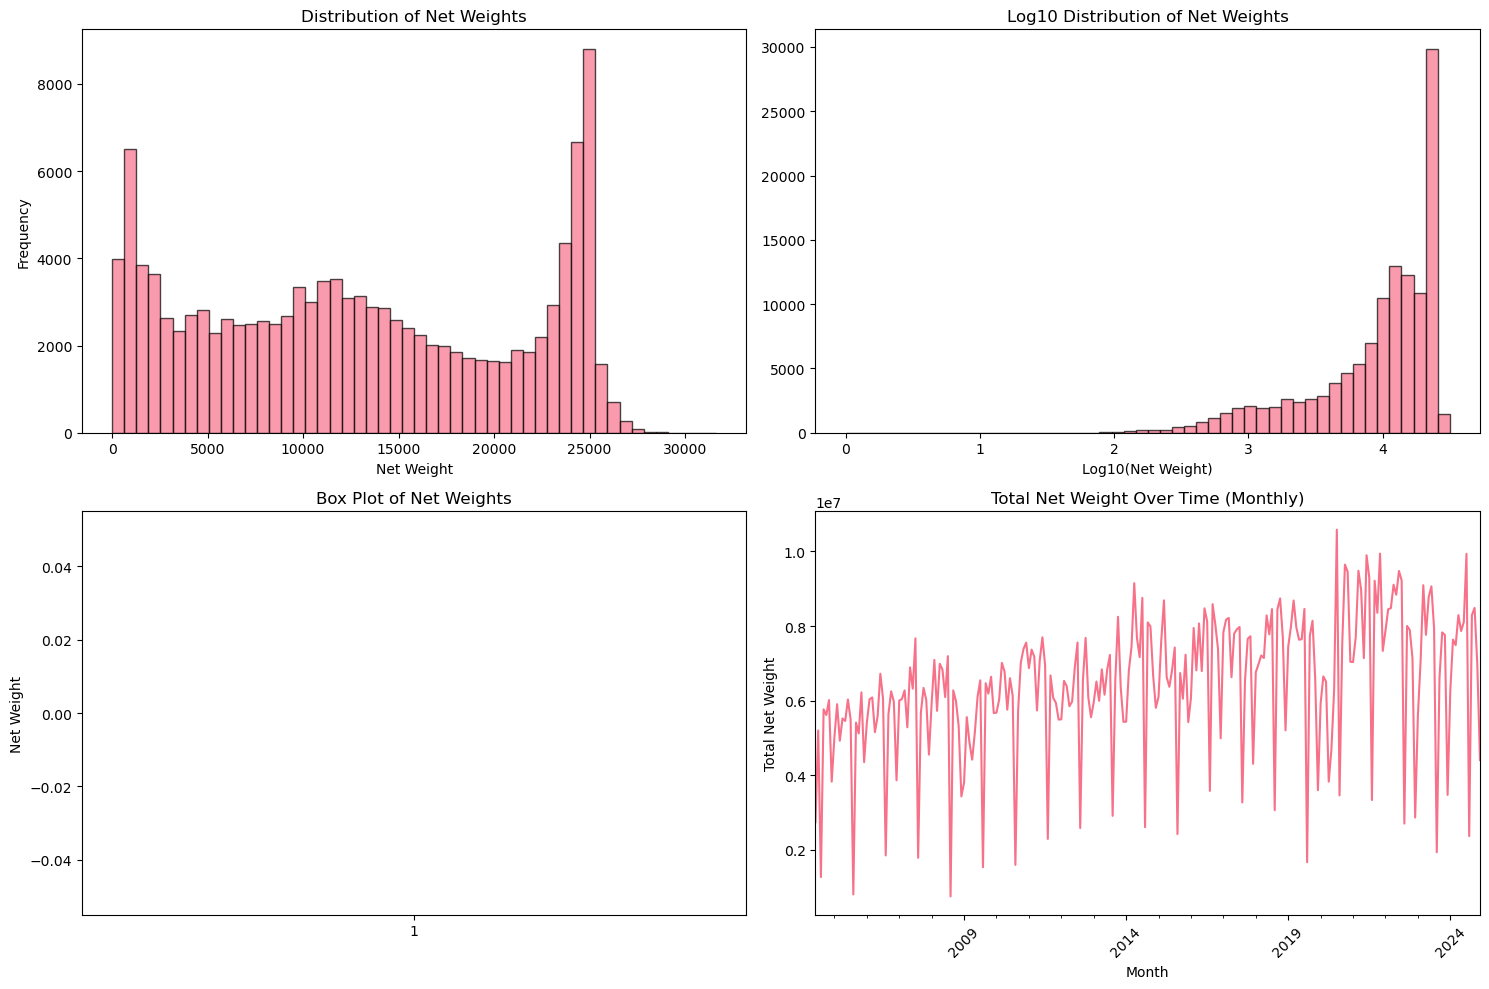

Net Weight Statistics:
count    122522.000000
mean      12972.566543
std        8264.652621
min           0.000000
25%        5660.000000
50%       12380.000000
75%       21120.000000
max       31626.000000
Name: net_weight, dtype: float64
Skewness: 0.067
Kurtosis: -1.309


In [73]:
# Explore individual features in detail
print("=== INDIVIDUAL FEATURE EXPLORATION ===\n")

# 1. Target variable exploration (net_weight)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of net weights
axes[0,0].hist(receivals['net_weight'], bins=50, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution of Net Weights')
axes[0,0].set_xlabel('Net Weight')
axes[0,0].set_ylabel('Frequency')

# Log-scale distribution (for better visualization if skewed)
positive_weights = receivals[receivals['net_weight'] > 0]['net_weight']
axes[0,1].hist(np.log10(positive_weights), bins=50, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Log10 Distribution of Net Weights')
axes[0,1].set_xlabel('Log10(Net Weight)')

# Box plot for net weights
axes[1,0].boxplot(receivals['net_weight'])
axes[1,0].set_title('Box Plot of Net Weights')
axes[1,0].set_ylabel('Net Weight')

# Net weights over time
monthly_weights = receivals.groupby(receivals['date_arrival'].dt.to_period('M'))['net_weight'].sum()
monthly_weights.plot(ax=axes[1,1])
axes[1,1].set_title('Total Net Weight Over Time (Monthly)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Total Net Weight')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics for key numerical features
print("Net Weight Statistics:")
print(receivals['net_weight'].describe())
print(f"Skewness: {receivals['net_weight'].skew():.3f}")
print(f"Kurtosis: {receivals['net_weight'].kurtosis():.3f}")

In [74]:
# Explore categorical features
print("\n=== CATEGORICAL FEATURES ===")

# Raw material IDs
print(f"Unique raw material IDs: {receivals['rm_id'].nunique()}")
print("Top 10 most common raw materials:")
print(receivals['rm_id'].value_counts().head(10))

# Product IDs
print(f"\nUnique product IDs: {receivals['product_id'].nunique()}")
print("Top 10 most common products:")
print(receivals['product_id'].value_counts().head(10))

# Suppliers
print(f"\nUnique suppliers: {receivals['supplier_id'].nunique()}")
print("Top 10 suppliers by volume:")
supplier_weights = receivals.groupby('supplier_id')['net_weight'].sum().sort_values(ascending=False)
print(supplier_weights.head(10))

# Receival status
print("\nReceival status distribution:")
print(receivals['receival_status'].value_counts())

# Purchase order status
print("\nPurchase order status distribution:")
print(purchase_orders['status'].value_counts())

# Material alloys (from materials dataset)
print("\nRaw material alloys:")
alloy_counts = materials['raw_material_alloy'].value_counts().head(15)
print(alloy_counts)


=== CATEGORICAL FEATURES ===
Unique raw material IDs: 203
Top 10 most common raw materials:
rm_id
2130.0    23621
1903.0    19337
2160.0    13507
2140.0     5343
2142.0     4625
2182.0     3370
1906.0     3112
2132.0     3100
1909.0     2697
2134.0     2677
Name: count, dtype: int64

Unique product IDs: 54
Top 10 most common products:
product_id
91900143.0    62537
91900302.0     9765
91900152.0     8447
91900146.0     6374
91901460.0     6266
91900330.0     6061
91900170.0     5268
91900160.0     4283
91901201.0     4264
91900871.0     3285
Name: count, dtype: int64

Unique suppliers: 255
Top 10 suppliers by volume:
supplier_id
10001    208300764.0
52036    134648521.0
63948     78275827.0
52064     63558409.0
69879     57196464.0
50363     54099785.0
70515     47144994.0
50420     46273305.0
50315     40725666.0
55251     38078960.0
Name: net_weight, dtype: float64

Receival status distribution:
receival_status
Completed             122448
Finished unloading       106
Start unloadin

## 5. Feature Pairs and Groups Exploration

=== FEATURE RELATIONSHIPS ===



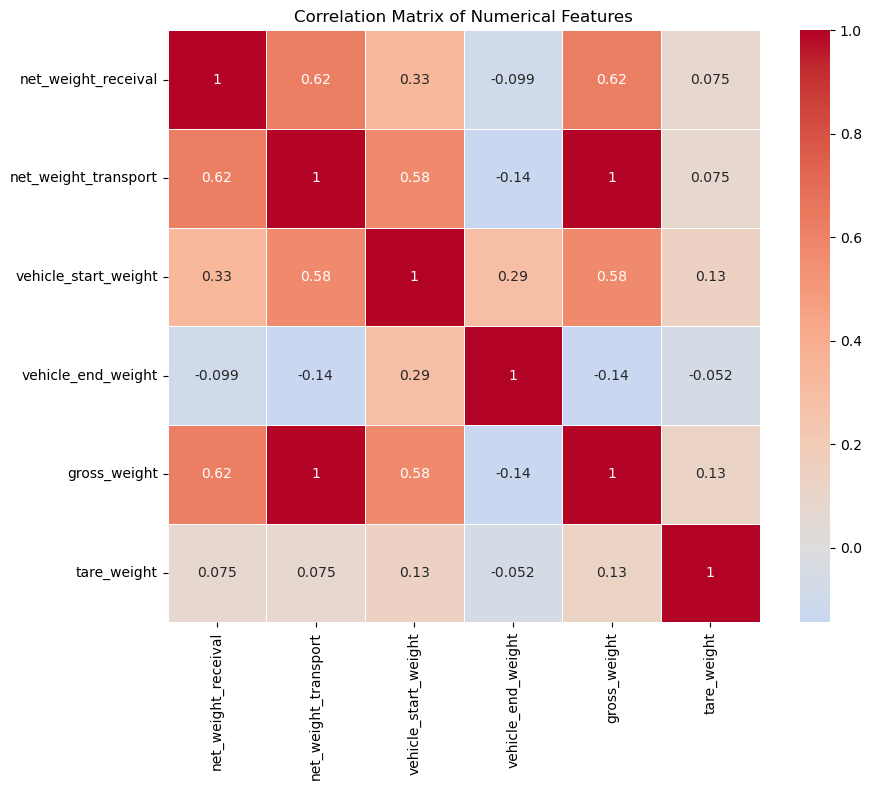

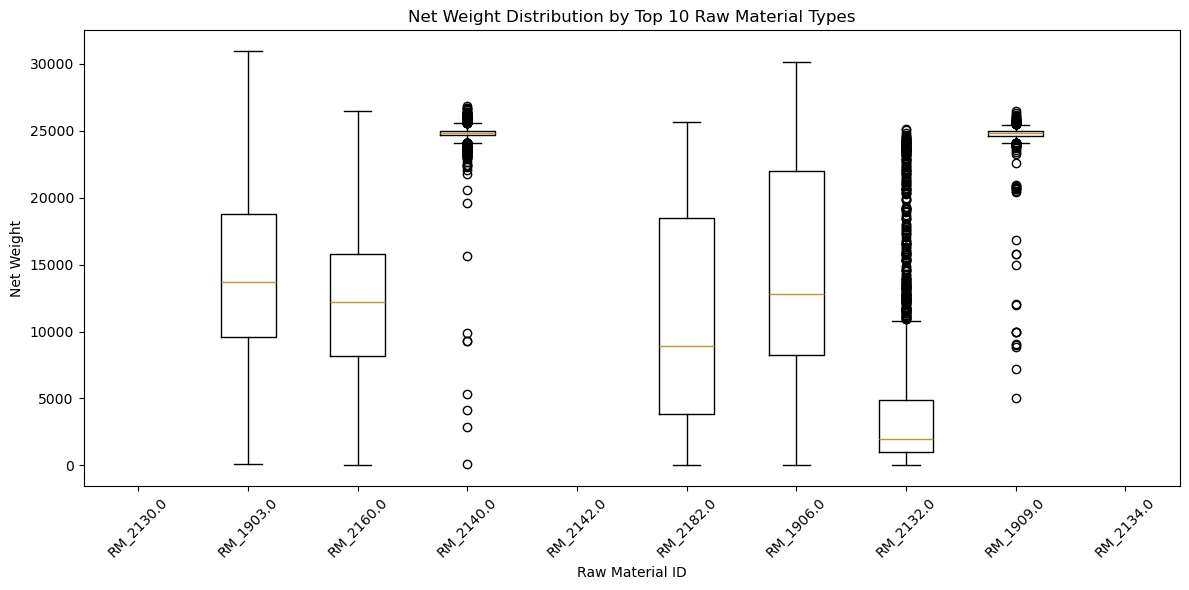

Average net weight by raw material type:
                mean          std  count
rm_id                                   
354.0   26028.750000  1369.942426      4
3222.0  25580.000000  1301.076477      2
1844.0  25120.000000          NaN      1
364.0   24990.603448   616.315906     58
3124.0  24982.697495  1842.384630    519
3921.0  24980.000000          NaN      1
2148.0  24975.000000  1252.422098     10
2128.0  24960.000000          NaN      1
4441.0  24942.857143    87.505102      7
342.0   24940.000000          NaN      1


In [75]:
# Explore relationships between features
print("=== FEATURE RELATIONSHIPS ===\n")

# Merge datasets for comprehensive analysis
# Merge receivals with materials information (kept for potential future feature joins)
receivals_materials = receivals.merge(materials, on=['rm_id', 'product_id'], how='left')

# Merge with transportation data
# Note: duplicate column names (e.g. net_weight) will receive suffixes so we can distinguish sources
full_data = receivals.merge(
    transportation,
    on=['rm_id', 'product_id', 'purchase_order_id', 'purchase_order_item_no', 'receival_item_no'],
    how='left',
    suffixes=('_receival', '_transport')
)

# 1. Correlation analysis for numerical features
# After merge, receivals net weight becomes net_weight_receival and transportation becomes net_weight_transport
numerical_cols_desired = [
    'net_weight_receival', 'net_weight_transport',
    'vehicle_start_weight', 'vehicle_end_weight',
    'gross_weight', 'tare_weight'
]

# Keep only columns that actually exist and are numeric
available_numeric_cols = []
for c in numerical_cols_desired:
    if c in full_data.columns:
        # Attempt coercion to numeric (in-place safe copy avoided for clarity)
        full_data[c] = pd.to_numeric(full_data[c], errors='coerce')
        if full_data[c].notna().sum() > 0:
            available_numeric_cols.append(c)

if len(available_numeric_cols) >= 2:
    correlation_data = full_data[available_numeric_cols].corr()
    if correlation_data.empty:
        print("Correlation matrix is empty after filtering numeric columns.")
    else:
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title('Correlation Matrix of Numerical Features')
        plt.tight_layout()
        plt.show()
else:
    print(f"Not enough numeric columns available for correlation (found: {available_numeric_cols}).")

# 2. Net weight by raw material type (uses original receivals dataframe)
plt.figure(figsize=(12, 6))
top_rm_ids = receivals['rm_id'].value_counts().head(10).index
rm_weights = []
rm_labels = []

for rm_id in top_rm_ids:
    weights = receivals[receivals['rm_id'] == rm_id]['net_weight']
    rm_weights.append(weights)
    rm_labels.append(f'RM_{rm_id}')

plt.boxplot(rm_weights, labels=rm_labels)
plt.title('Net Weight Distribution by Top 10 Raw Material Types')
plt.xlabel('Raw Material ID')
plt.ylabel('Net Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average net weight by raw material type:")
avg_weights_by_rm = receivals.groupby('rm_id')['net_weight'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print(avg_weights_by_rm.head(10))


=== TEMPORAL PATTERNS ===


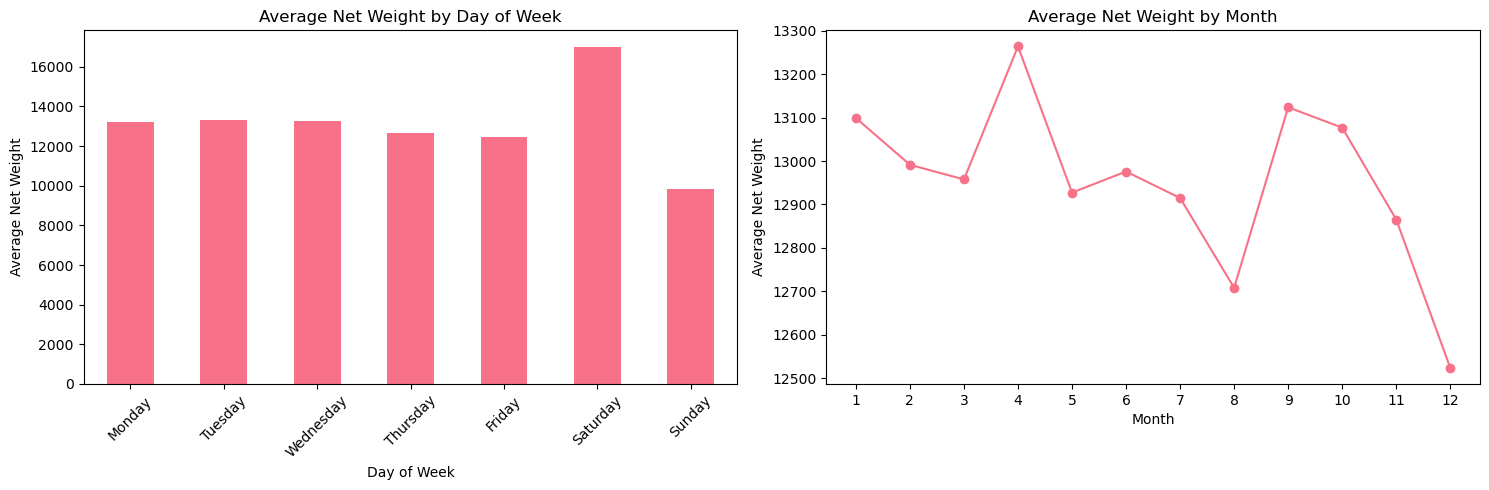


Supplier-Product analysis:
Top 10 supplier-product combinations by total weight:
                        deliveries  avg_weight  total_weight
supplier_id product_id                                      
10001       91900152.0        8419    24741.75   208300764.0
52036       91900143.0        9204    13226.07   121732751.0
63948       91900143.0        3957    17517.25    69315776.0
52064       91900143.0        3295    17339.61    57134006.0
50363       91900143.0        4256    12172.84    51807609.0
69879       91900143.0        4004    11278.67    45159812.0
50420       91900143.0        2835    15143.74    42932508.0
70515       91901460.0        1835    18220.87    33435300.0
50390       91900143.0        1788    18100.91    32364424.0
55251       91900143.0        2267    12902.51    29249985.0


In [76]:
# 3. Temporal patterns
print("\n=== TEMPORAL PATTERNS ===")

# Weight patterns by day of week
receivals['day_of_week'] = receivals['date_arrival'].dt.dayofweek
receivals['day_name'] = receivals['date_arrival'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average weight by day of week
daily_avg = receivals.groupby('day_name')['net_weight'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = daily_avg.reindex(day_order)
daily_avg.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Net Weight by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Net Weight')
axes[0].tick_params(axis='x', rotation=45)

# Monthly seasonality
receivals['month'] = receivals['date_arrival'].dt.month
monthly_avg = receivals.groupby('month')['net_weight'].mean()
monthly_avg.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Average Net Weight by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Net Weight')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# 4. Supplier and product relationships
print("\nSupplier-Product analysis:")
supplier_product = receivals.groupby(['supplier_id', 'product_id']).agg({
    'net_weight': ['count', 'mean', 'sum']
}).round(2)

supplier_product.columns = ['deliveries', 'avg_weight', 'total_weight']
supplier_product = supplier_product.sort_values('total_weight', ascending=False)
print("Top 10 supplier-product combinations by total weight:")
print(supplier_product.head(10))

## 6. Data Cleaning and Quality Assessment

=== DATA QUALITY ASSESSMENT ===


Purchase Orders Dataset:
Shape: (33171, 12)
Missing values:
modified_date_time    1.48
unit_id               0.13
unit                  0.13
dtype: float64
Duplicate rows: 0

Receivals Dataset:
Shape: (122590, 14)
Missing values:
batch_id                  47.17
net_weight                 0.06
rm_id                      0.05
product_id                 0.05
purchase_order_id          0.04
purchase_order_item_no     0.04
dtype: float64
Duplicate rows: 3

Materials Dataset:
Shape: (1218, 6)
Missing values:
rm_id                       0.08
product_id                  0.08
product_version             0.08
raw_material_alloy          0.08
raw_material_format_type    0.08
stock_location              0.08
dtype: float64
Duplicate rows: 0

Transportation Dataset:
Shape: (122590, 23)
Missing values:
chips                     93.65
ice                       93.64
water                     93.64
cardboard                 93.61
packaging                 93.60
other 

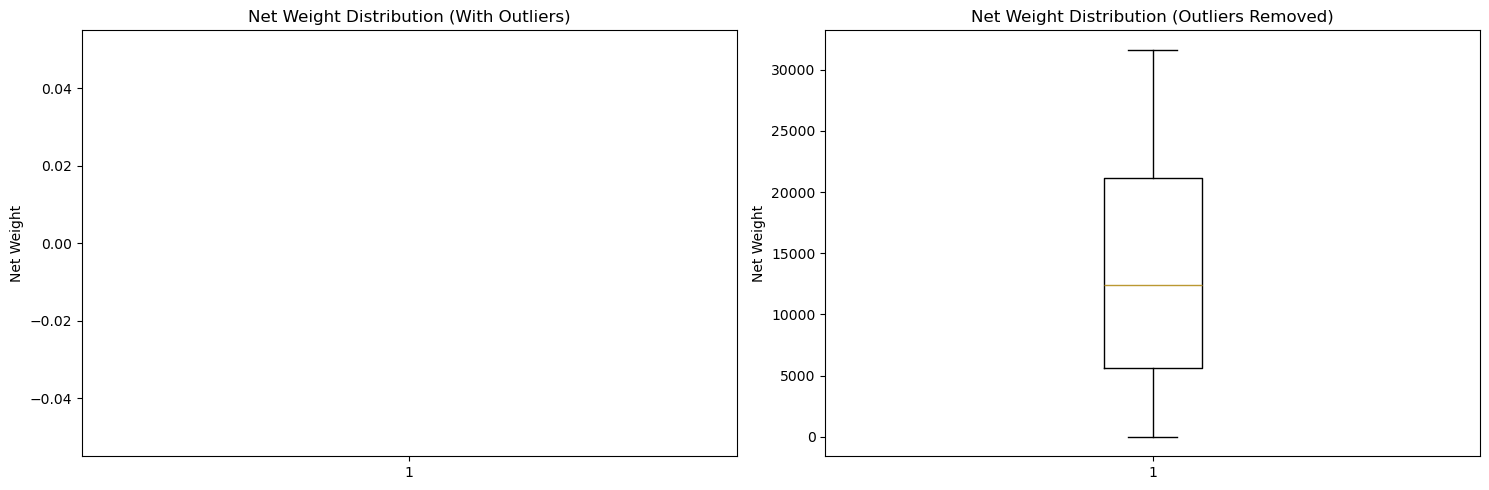

Original data points: 122590
After outlier removal: 122522
Percentage retained: 99.94%


In [77]:
# Comprehensive data quality assessment and cleaning
print("=== DATA QUALITY ASSESSMENT ===\n")

datasets = {
    'Purchase Orders': purchase_orders,
    'Receivals': receivals,
    'Materials': materials,
    'Transportation': transportation
}

for name, df in datasets.items():
    print(f"\n{name} Dataset:")
    print(f"Shape: {df.shape}")
    print(f"Missing values:")
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_info = missing_pct[missing_pct > 0].sort_values(ascending=False)
    if len(missing_info) > 0:
        print(missing_info)
    else:
        print("No missing values")
    
    print(f"Duplicate rows: {df.duplicated().sum()}")

# Identify and handle outliers in net_weight
print("\n=== OUTLIER DETECTION ===")

Q1 = receivals['net_weight'].quantile(0.25)
Q3 = receivals['net_weight'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = receivals[(receivals['net_weight'] < lower_bound) | (receivals['net_weight'] > upper_bound)]
print(f"Number of outliers in net_weight: {len(outliers)} ({len(outliers)/len(receivals)*100:.2f}%)")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before outlier removal
axes[0].boxplot(receivals['net_weight'])
axes[0].set_title('Net Weight Distribution (With Outliers)')
axes[0].set_ylabel('Net Weight')

# After outlier removal
clean_weights = receivals[(receivals['net_weight'] >= lower_bound) & (receivals['net_weight'] <= upper_bound)]['net_weight']
axes[1].boxplot(clean_weights)
axes[1].set_title('Net Weight Distribution (Outliers Removed)')
axes[1].set_ylabel('Net Weight')

plt.tight_layout()
plt.show()

print(f"Original data points: {len(receivals)}")
print(f"After outlier removal: {len(clean_weights)}")
print(f"Percentage retained: {len(clean_weights)/len(receivals)*100:.2f}%")

In [78]:
# Data consistency checks
print("\n=== DATA CONSISTENCY CHECKS ===")

# Check consistency between receivals and transportation data
print("1. Consistency between Receivals and Transportation:")
common_records = pd.merge(receivals, transportation, 
                         on=['rm_id', 'product_id', 'purchase_order_id', 'purchase_order_item_no', 'receival_item_no'],
                         how='inner')

weight_diff = abs(common_records['net_weight_x'] - common_records['net_weight_y'])
inconsistent_weights = weight_diff > 0.01  # Allow for small rounding differences

print(f"Records with matching keys: {len(common_records)}")
print(f"Records with inconsistent net weights: {inconsistent_weights.sum()}")
print(f"Maximum weight difference: {weight_diff.max():.2f}")

# Check transportation weight calculations
print("\n2. Transportation Weight Calculations:")
transport_clean = transportation.dropna(subset=['vehicle_start_weight', 'vehicle_end_weight', 'gross_weight', 'tare_weight', 'net_weight'])

if len(transport_clean) > 0:
    # Check if gross_weight = vehicle_start_weight - vehicle_end_weight
    calc_gross = transport_clean['vehicle_start_weight'] - transport_clean['vehicle_end_weight']
    gross_diff = abs(calc_gross - transport_clean['gross_weight'])
    
    # Check if net_weight = gross_weight - tare_weight
    calc_net = transport_clean['gross_weight'] - transport_clean['tare_weight']
    net_diff = abs(calc_net - transport_clean['net_weight'])
    
    print(f"Inconsistent gross weight calculations: {(gross_diff > 0.01).sum()}")
    print(f"Inconsistent net weight calculations: {(net_diff > 0.01).sum()}")

# Feature engineering suggestions
print("\n=== FEATURE ENGINEERING OPPORTUNITIES ===")

print("1. Temporal features:")
print("   - Day of week, month, quarter, year")
print("   - Days since last receival for each rm_id")
print("   - Rolling averages of weights")

print("\n2. Aggregated features:")
print("   - Historical average weight per rm_id")
print("   - Supplier reliability metrics")
print("   - Seasonal patterns per material type")

print("\n3. Interaction features:")
print("   - Supplier-material combinations")
print("   - Time-based material demand patterns")

# Create a sample engineered feature
receivals_sample = receivals.copy()
receivals_sample['days_since_epoch'] = (receivals_sample['date_arrival'] - receivals_sample['date_arrival'].min()).dt.days

# Calculate rolling average for each rm_id
receivals_sample = receivals_sample.sort_values(['rm_id', 'date_arrival'])
receivals_sample['rolling_avg_7d'] = receivals_sample.groupby('rm_id')['net_weight'].rolling(window=7, min_periods=1).mean().reset_index(0, drop=True)

print(f"\nSample engineered feature (7-day rolling average):")
print(receivals_sample[['rm_id', 'date_arrival', 'net_weight', 'rolling_avg_7d']].head(10))


=== DATA CONSISTENCY CHECKS ===
1. Consistency between Receivals and Transportation:
Records with matching keys: 2191712
Records with inconsistent net weights: 2058548
Maximum weight difference: 30130.00

2. Transportation Weight Calculations:
Inconsistent gross weight calculations: 52613
Inconsistent net weight calculations: 4

=== FEATURE ENGINEERING OPPORTUNITIES ===
1. Temporal features:
   - Day of week, month, quarter, year
   - Days since last receival for each rm_id
   - Rolling averages of weights

2. Aggregated features:
   - Historical average weight per rm_id
   - Supplier reliability metrics
   - Seasonal patterns per material type

3. Interaction features:
   - Supplier-material combinations
   - Time-based material demand patterns

Sample engineered feature (7-day rolling average):
      rm_id        date_arrival  net_weight  rolling_avg_7d
104   342.0 2004-06-23 06:29:00     24940.0    24940.000000
3208  343.0 2005-03-29 07:32:00     21760.0    21760.000000
679   345.0

## Modeling Strategy & Hyperparameter Justification


### Prophet Hyperparameters
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| growth | linear | No saturation/capacity ceiling observed; linear keeps trend simple. |
| yearly_seasonality | True | Clear annual cycles in monthly counts across years. |
| weekly_seasonality | False | Weak intra-week signal; disabling reduces variance/overfit. |
| daily_seasonality | False | No intra-day patterns; data is daily aggregated. |
| seasonality_mode | multiplicative | Seasonal amplitude scales with level (proportional fluctuations). |
| changepoint_prior_scale | 0.02 | Restricts spurious trend shifts, important given forecast gap before 2025. |
| changepoint_range | 0.8 | Excludes sparse tail right before forecast horizon from CP search. |
| seasonality_prior_scale | 0.69 | Coarse grid (0.1–1.0) minimized τ=0.2 pinball (quantile) loss. |
| holidays_prior_scale | 0.56 | Moderates volumes around Norwegian holidays without over-suppression. |
| regressor: is_weekday | binary (0/1) | Captures weekend slowdown without full weekly seasonality. |

### Activity & Data Quality Filters
- Minimum observations per material: 20 (below this, seasonal components became unstable and error variance high).
- Recent activity window: 90 days before 2025‑01‑01. Materials inactive in that window are zeroed during forecast horizon to avoid phantom deliveries.
- Deterministic ordering: Sort rm_id list to make model sequence stable.
- Fixed seeds (`numpy` + `random`) before each fit to eliminate stochastic variance.

### Post-Processing (Conservative Adjustment)
1. Scale daily predictions: `yhat_scaled = yhat * 0.62`.
2. Clip at 0 to enforce physical non-negativity.
3. Cumulative sum per rm_id to match evaluation format (cumulative weight up to end date).

Why 0.62? Rolling 90‑day backtests (final 18 historical months) produced empirical residual ratios (actual / prediction). Selecting near the 0.2 quantile induced systematic underestimation consistent with asymmetric loss at τ=0.2 (overestimation penalized more heavily).

### Data Generation → Modeling Adaptation
| Observation | Modeling Response |
|-------------|------------------|
| Long history + gap before 2025 | Conservative trend (low CP prior) & exclude late sparse period. |
| Annual seasonality dominant | Enable yearly; disable weak weekly/daily. |
| Measurement noise (transport vs receivals mismatch) | Downscale predictions; avoid high seasonality priors. |
| Dormant materials present | Activity filter sets future weights to zero. |
| Asymmetric evaluation (over > under penalty) | Quantile-aligned scaling (0.62) to bias low. |
| Level-dependent variance | Multiplicative seasonal mode chosen. |

### Risks & Mitigations
| Risk | Mitigation |
|------|------------|
| Excessive underestimation | Re-evaluate scaling factor with expanded validation slice. |
| Material reactivation mid-horizon | Future improvement: incorporate PO pipeline or lead indicators. |
| Uncaptured structural break early 2025 | Monitor live deviations; increase CP prior if justified. |
| Holiday over-adjustment | Multiplicative mode applies proportional reduction; review residuals post-holiday. |
